# Mid × high resolution: baseline e filtro + envelope

Comparação resumida de **Dice arterial**, **sucesso dos óstios** e **mudança pareada do Dice** nos splits `train`, `val` e `test`. A versão nova inclui filtro, envelope, `lower100` e `pad2`; portanto, a comparação representa a evolução completa do pipeline, não uma ablação isolada.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

repo_candidates = (Path.cwd(), *Path.cwd().parents)
REPO_ROOT = next(
    path
    for path in repo_candidates
    if (path / "src").is_dir() and (path / "config").is_dir()
)
src_dir = str(REPO_ROOT / "src")
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

from utils.comparison_utils.run_comparison import (  # noqa: E402
    build_dice_ostia_overview,
    compare_paired_run_matrix,
    load_validated_comparison_runs,
)
from utils.project.notebook_env import configure_notebook_environment  # noqa: E402
from utils.visualization.comparison import (  # noqa: E402
    plot_grouped_metric_panels,
)

REPO_ROOT = configure_notebook_environment(chdir_to_src=False)
plt.style.use("seaborn-v0_8-whitegrid")

## Runs e validação

Os baselines são as referências anteriores. Os candidatos são os runs selecionados com filtro + envelope, `lower100/pad2` e, no treino high resolution, raio de abertura efetivo correto.

In [2]:
RUNS = {
    (
        "mid_res",
        "baseline",
        "train",
    ): "output/segmentation/runs/mid_res/current_baseline_p99_9/train/2026-08-06_18-43-37",
    (
        "mid_res",
        "baseline",
        "val",
    ): "output/segmentation/runs/mid_res/current_baseline_p99_9/val/2026-08-06_22-43-14",
    (
        "mid_res",
        "baseline",
        "test",
    ): "output/segmentation/runs/mid_res/current_baseline_p99_9/test/2026-08-06_10-04-22",
    (
        "mid_res",
        "filtro_envelope",
        "train",
    ): "output/segmentation/runs/mid_res/aorta_segmentation_experiments/train/ostia_localization/lower100_pad2/2026-09-06_08-08-25",
    (
        "mid_res",
        "filtro_envelope",
        "val",
    ): "output/segmentation/runs/mid_res/aorta_segmentation_experiments/val/ostia_validation270/lower100_pad2/2026-09-07_07-15-15",
    (
        "mid_res",
        "filtro_envelope",
        "test",
    ): "output/segmentation/runs/mid_res/aorta_segmentation_experiments/test/ostia_comparison/lower100_pad2/2026-09-07_10-37-38",
    (
        "high_res",
        "baseline",
        "train",
    ): "output/segmentation/runs/high_res/reference/train/2026-04-21_08-42-13",
    (
        "high_res",
        "baseline",
        "val",
    ): "output/segmentation/runs/high_res/reference/val/2026-04-21_08-42-13",
    (
        "high_res",
        "baseline",
        "test",
    ): "output/segmentation/runs/high_res/reference/test/2026-04-28_14-28-44",
    (
        "high_res",
        "filtro_envelope",
        "train",
    ): "output/segmentation/runs/high_res/aorta_segmentation_experiments/train/filter_envelope_lower100_pad2/2026-09-15_11-08-42",
    (
        "high_res",
        "filtro_envelope",
        "val",
    ): "output/segmentation/runs/high_res/aorta_segmentation_experiments/val/filter_envelope_lower100_pad2/2026-09-12_07-51-48",
    (
        "high_res",
        "filtro_envelope",
        "test",
    ): "output/segmentation/runs/high_res/aorta_segmentation_experiments/test/filter_envelope_lower100_pad2/2026-09-13_14-06-44",
}
EXPECTED_IMAGES = {"train": 30, "val": 270, "test": 700}
RESOLUTION_LABELS = {"mid_res": "Mid resolution", "high_res": "High resolution"}
STAGE_LABELS = {"baseline": "Baseline anterior", "filtro_envelope": "Filtro + envelope"}
SPLIT_LABELS = {"train": "Treino", "val": "Validação", "test": "Teste"}
split_paths = {
    f"{resolution}:{stage}": {
        split: REPO_ROOT / directory / "numeric"
        for (item_resolution, item_stage, split), directory in RUNS.items()
        if item_resolution == resolution and item_stage == stage
    }
    for resolution in RESOLUTION_LABELS
    for stage in STAGE_LABELS
}

frames = load_validated_comparison_runs(split_paths, EXPECTED_IMAGES)
print("12 coortes completas e pareadas por IMG_ID.")

12 coortes completas e pareadas por IMG_ID.


In [3]:
VARIANT_LABELS = {
    f"{resolution}:{stage}": STAGE_LABELS[stage]
    for resolution in RESOLUTION_LABELS
    for stage in STAGE_LABELS
}
overview = build_dice_ostia_overview(
    frames, variant_labels=VARIANT_LABELS, split_labels=SPLIT_LABELS
)
overview["resolution"] = overview["variant"].str.split(":").str[0]
overview["resolução"] = overview["resolution"].map(RESOLUTION_LABELS)

## 1. Dice score

A média considera todos os exames, inclusive Dice zero.

,resolução,variant_label,split_label,num_images,mean_dice
0,Mid resolution,Baseline anterior,Treino,30,0.6148
1,Mid resolution,Baseline anterior,Validação,270,0.5879
2,Mid resolution,Baseline anterior,Teste,700,0.5930
3,Mid resolution,Filtro + envelope,Treino,30,0.6288
4,Mid resolution,Filtro + envelope,Validação,270,0.5992
5,Mid resolution,Filtro + envelope,Teste,700,0.6018
6,High resolution,Baseline anterior,Treino,30,0.5590
7,High resolution,Baseline anterior,Validação,270,0.4807
8,High resolution,Baseline anterior,Teste,700,0.4684
9,High resolution,Filtro + envelope,Treino,30,0.5720


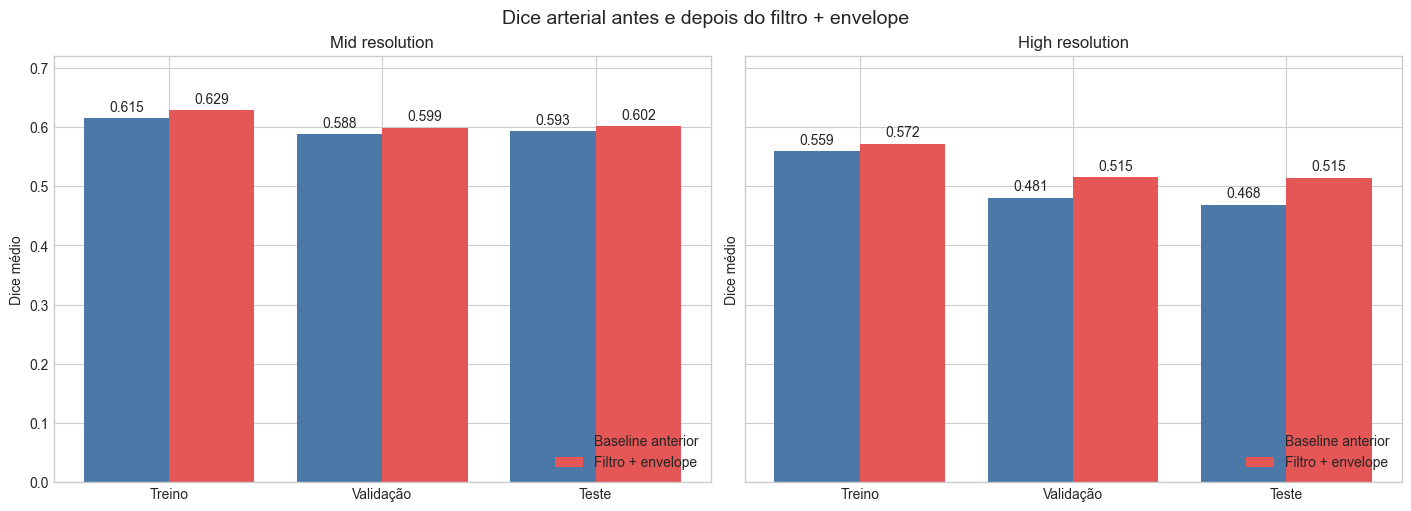

In [4]:
display(
    overview[
        ["resolução", "variant_label", "split_label", "num_images", "mean_dice"]
    ].round(4)
)
plot_grouped_metric_panels(
    overview,
    panel_col="resolução",
    group_col="variant_label",
    x_col="split_label",
    metric_col="mean_dice",
    panel_order=list(RESOLUTION_LABELS.values()),
    group_order=list(STAGE_LABELS.values()),
    x_order=list(SPLIT_LABELS.values()),
    colors={"Baseline anterior": "#4C78A8", "Filtro + envelope": "#E45756"},
    ylabel="Dice médio",
    title="Dice arterial antes e depois do filtro + envelope",
    ylim=(0, 0.72),
    value_format="%.3f",
)
plt.show()

## 2. Taxa de acerto dos óstios

Sucesso corresponde a `both_correct + both_tolerable`, usando o total de exames do split como denominador.

,resolução,variant_label,split_label,num_images,ostia_success_count,ostia_success_percent
0,Mid resolution,Baseline anterior,Treino,30,27,90.00
1,Mid resolution,Baseline anterior,Validação,270,226,83.70
2,Mid resolution,Baseline anterior,Teste,700,578,82.57
3,Mid resolution,Filtro + envelope,Treino,30,29,96.67
4,Mid resolution,Filtro + envelope,Validação,270,229,84.81
5,Mid resolution,Filtro + envelope,Teste,700,599,85.57
6,High resolution,Baseline anterior,Treino,30,27,90.00
7,High resolution,Baseline anterior,Validação,270,195,72.22
8,High resolution,Baseline anterior,Teste,700,500,71.43
9,High resolution,Filtro + envelope,Treino,30,27,90.00


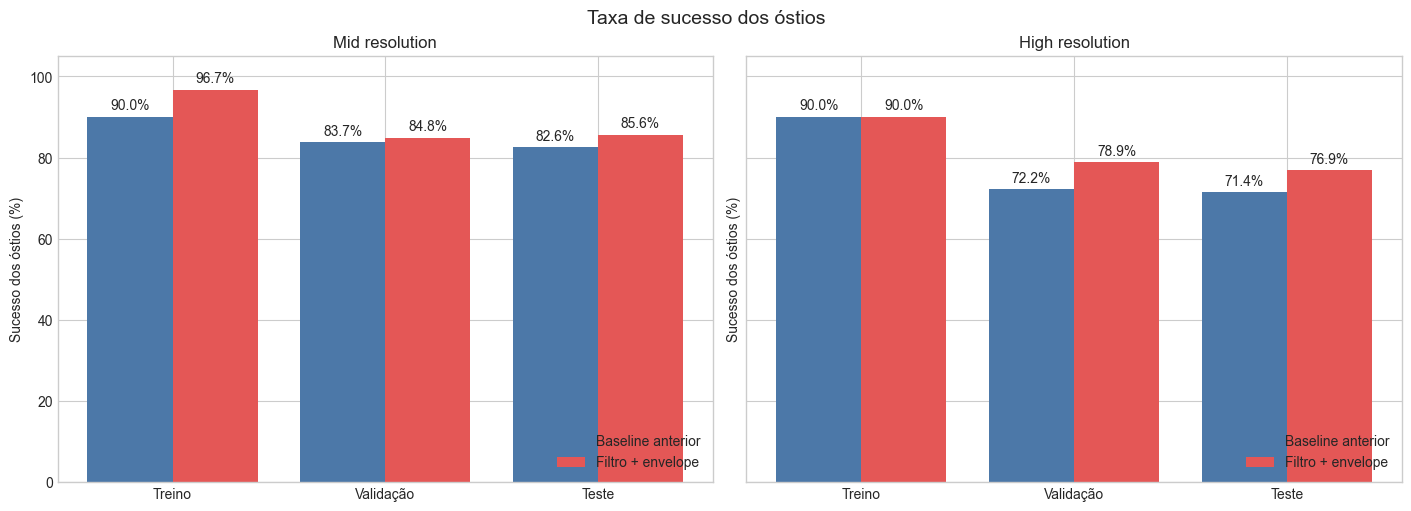

In [5]:
display(
    overview[
        [
            "resolução",
            "variant_label",
            "split_label",
            "num_images",
            "ostia_success_count",
            "ostia_success_percent",
        ]
    ].round(2)
)
plot_grouped_metric_panels(
    overview,
    panel_col="resolução",
    group_col="variant_label",
    x_col="split_label",
    metric_col="ostia_success_percent",
    panel_order=list(RESOLUTION_LABELS.values()),
    group_order=list(STAGE_LABELS.values()),
    x_order=list(SPLIT_LABELS.values()),
    colors={"Baseline anterior": "#4C78A8", "Filtro + envelope": "#E45756"},
    ylabel="Sucesso dos óstios (%)",
    title="Taxa de sucesso dos óstios",
    ylim=(0, 105),
    value_format="%.1f%%",
)
plt.show()

## 3. Teste pareado de Wilcoxon

**Δ Dice = filtro + envelope − baseline**; positivo favorece o pipeline novo. `W` é a estatística do teste de Wilcoxon bilateral e deve ser interpretada junto com o p-valor.

Cada comparação usa os mesmos exames pareados por `IMG_ID`. Holm é aplicado aos seis testes de mid/high resolution nos conjuntos de treino, validação e teste.

O desempenho é apresentado como mediana [Q1–Q3]. O IC95% corresponde ao Δ Dice médio e usa bootstrap pareado com 10.000 reamostragens e semente fixa 42. `Melhorou/piorou/igual` mostra a direção da mudança exame a exame.

`p (Holm) < 0,05` indica diferença estatística após ajuste, não necessariamente melhora clinicamente relevante.

In [6]:
paired_stats = compare_paired_run_matrix(
    frames,
    [
        ("mid_res:baseline", "mid_res:filtro_envelope"),
        ("high_res:baseline", "high_res:filtro_envelope"),
    ],
    split_labels=SPLIT_LABELS,
)
paired_stats["resolution"] = paired_stats["reference"].str.split(":").str[0]
paired_stats["resolução"] = paired_stats["resolution"].map(RESOLUTION_LABELS)

# Formata desempenho e intervalo sem descartar os valores numéricos originais.
paired_stats["desempenho_baseline"] = paired_stats.apply(
    lambda row: (
        f"{row['baseline_median_dice']:.3f} "
        f"[{row['baseline_q1_dice']:.3f}–{row['baseline_q3_dice']:.3f}]"
    ),
    axis=1,
)
paired_stats["desempenho_filtro_envelope"] = paired_stats.apply(
    lambda row: (
        f"{row['candidate_median_dice']:.3f} "
        f"[{row['candidate_q1_dice']:.3f}–{row['candidate_q3_dice']:.3f}]"
    ),
    axis=1,
)
paired_stats["ic95_delta"] = paired_stats.apply(
    lambda row: (
        f"[{row['mean_delta_ci_95_low']:.4f}; {row['mean_delta_ci_95_high']:.4f}]"
    ),
    axis=1,
)
paired_stats["desfechos"] = paired_stats.apply(
    lambda row: (
        f"{int(row['improved_images'])}/"
        f"{int(row['worse_images'])}/"
        f"{int(row['unchanged_images'])}"
    ),
    axis=1,
)

wilcoxon_view = paired_stats[
    [
        "resolução",
        "split_label",
        "paired_images",
        "desempenho_baseline",
        "desempenho_filtro_envelope",
        "mean_delta_dice",
        "ic95_delta",
        "wilcoxon_statistic",
        "p_value",
        "desfechos",
        "significant",
    ]
].copy()
wilcoxon_view["significant"] = wilcoxon_view["significant"].map(
    {True: "Diferença detectada", False: "Não significativa"}
)
wilcoxon_view = wilcoxon_view.rename(
    columns={
        "resolução": "Resolução",
        "split_label": "Conjunto",
        "paired_images": "N",
        "desempenho_baseline": "Baseline: mediana [IQR]",
        "desempenho_filtro_envelope": "Filtro + envelope: mediana [IQR]",
        "mean_delta_dice": "Δ Dice médio",
        "ic95_delta": "IC95% do Δ médio",
        "wilcoxon_statistic": "W",
        "p_value": "p bruto",
        "desfechos": "Melhorou/piorou/igual",
        "significant": "Conclusão",
    }
)
with pd.option_context("display.float_format", "{:.4g}".format):
    display(wilcoxon_view)

,Resolução,Conjunto,N,Baseline: mediana [IQR],Filtro + envelope: mediana [IQR],Δ Dice médio,IC95% do Δ médio,W,p bruto,Melhorou/piorou/igual,Conclusão
0,Mid resolution,Treino,30,0.631 [0.546–0.699],0.657 [0.560–0.707],0.01399,[-0.0227; 0.0512],11,0.327,5/3/22,Não significativa
1,High resolution,Treino,30,0.581 [0.500–0.625],0.584 [0.532–0.627],0.01301,[-0.0186; 0.0444],128,0.05296,21/8/1,Não significativa
2,Mid resolution,Validação,270,0.654 [0.530–0.715],0.659 [0.555–0.714],0.01134,[-0.0059; 0.0291],1986,0.3526,48/46/176,Não significativa
3,High resolution,Validação,270,0.552 [0.384–0.634],0.579 [0.451–0.644],0.03475,[0.0110; 0.0581],1.023e+04,1.034e-07,166/91/13,Diferença detectada
4,Mid resolution,Teste,700,0.663 [0.552–0.710],0.668 [0.569–0.711],0.008756,[-0.0016; 0.0194],1.026e+04,0.172,107/107/486,Não significativa
5,High resolution,Teste,700,0.531 [0.377–0.624],0.578 [0.455–0.638],0.04613,[0.0312; 0.0613],7.354e+04,6.13e-15,435/236/29,Diferença detectada
